# Inspección de la capa invariante (`walkers.parquet`)

Chequeos visuales del artefacto producido por `src/simulador/invariant/build.py`
para validar que la población, rutas y NDVI de ruta hacen sentido antes de
seguir con la capa de escenario.

Si aún no generaste el artefacto, descomenta la primera celda para correrlo.

---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import config as cfg

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── (opcional) generar el artefacto si no existe ──
# from src.simulador.invariant.build import build_invariant
# build_invariant()

walkers = pd.read_parquet(cfg.FP_WALKERS)
manz    = gpd.read_parquet(cfg.FP_MANZ_SIM).to_crs(cfg.CRS_PROJ)
print(f'Zona: {cfg.ZONA} | walkers: {len(walkers):,}')
walkers.head()

Zona: suroriente | walkers: 8,243


,agent_id,MANZENT,COD_MANZANA,vuln_group,purpose_group_model,ndvi_mean,ndvi_norm,x_rep,y_rep,origin_node,dest_node,dest_id,route_length_m,ndvi_route,x_dest,y_dest
0,5,1.311001e+13,3,baja,comercio,0.112740,0.152268,350358.289034,6.291021e+06,9394616251,11895385584,com_1482,329.794,0.126454,350436.306711,6.290846e+06
1,16,1.311001e+13,6,media,salud,0.142727,0.197178,350529.543852,6.290858e+06,13064230851,4458277611,salud_47,1021.597,0.127133,350997.384832,6.290125e+06
2,18,1.311001e+13,7,baja,comercio,0.099936,0.133093,350566.779616,6.290827e+06,13683510751,5509625134,com_1686,229.062,0.140711,350728.326971,6.290859e+06
3,22,1.311001e+13,11,media,comercio,0.115437,0.156308,350749.276397,6.290532e+06,4009634059,4458277609,com_2066,536.006,0.115437,350653.082166,6.290532e+06
4,26,1.311001e+13,11,media,comercio,0.115437,0.156308,350749.276397,6.290532e+06,4009634059,4009634069,com_1742,78.111,0.115437,350772.051121,6.290612e+06


## 1. ¿Cuántos agentes por manzana? (esperado: ~1 por cada 10 AM 60+)

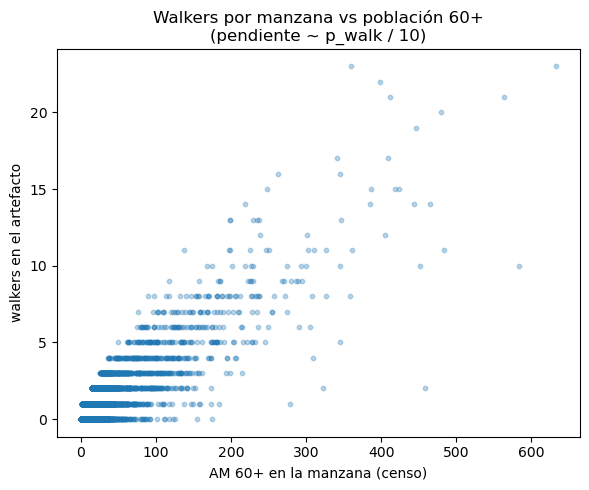

walkers totales: 8243
manzanas con al menos 1 walker: 4275 / 6782


In [2]:
# Agentes generados por manzana vs población 60+ (antes del filtro de caminata)
por_manz = walkers.groupby('MANZENT').size().rename('n_walkers')
chk = manz[['MANZENT', 'n_edad_60_mas']].merge(por_manz, on='MANZENT', how='left').fillna(0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(chk['n_edad_60_mas'], chk['n_walkers'], alpha=0.3, s=10)
ax.set_xlabel('AM 60+ en la manzana (censo)')
ax.set_ylabel('walkers en el artefacto')
ax.set_title('Walkers por manzana vs población 60+\n(pendiente ~ p_walk / 10)')
plt.tight_layout(); plt.show()

print('walkers totales:', len(walkers))
print('manzanas con al menos 1 walker:', (chk['n_walkers'] > 0).sum(), '/', len(chk))

## 2. Propósito del viaje por grupo de vulnerabilidad

purpose_group_model  areas_verdes  comercio  salud
vuln_group                                        
baja                         19.8      75.8    4.4
media                        16.1      77.4    6.5
alta                         13.4      78.0    8.6


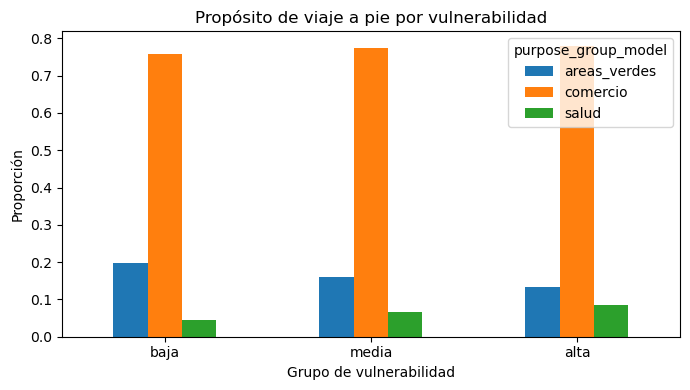

In [3]:
tab = (pd.crosstab(walkers['vuln_group'], walkers['purpose_group_model'], normalize='index')
         .reindex(['baja', 'media', 'alta']))
print((tab * 100).round(1))

ax = tab.plot(kind='bar', figsize=(7, 4), rot=0)
ax.set_title('Propósito de viaje a pie por vulnerabilidad')
ax.set_ylabel('Proporción'); ax.set_xlabel('Grupo de vulnerabilidad')
plt.tight_layout(); plt.show()

## 3. Distribución de largos de ruta (por propósito)

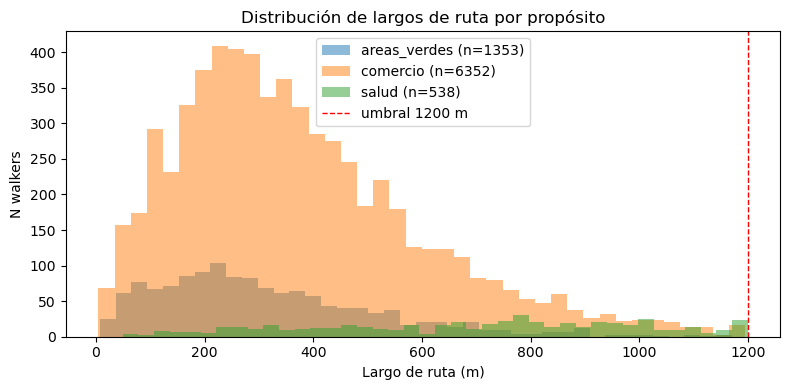

                      count   mean    std   min    25%    50%    75%     max
purpose_group_model                                                         
areas_verdes         1353.0  314.0  205.0   7.0  167.0  272.0  421.0  1170.0
comercio             6352.0  373.0  225.0   4.0  210.0  332.0  498.0  1195.0
salud                 538.0  697.0  296.0  49.0  462.0  740.0  936.0  1199.0


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for p, sub in walkers.groupby('purpose_group_model'):
    ax.hist(sub['route_length_m'], bins=40, alpha=0.5, label=f'{p} (n={len(sub)})')
ax.axvline(cfg.UMBRAL_CAMINATA_M, color='red', ls='--', lw=1, label=f'umbral {cfg.UMBRAL_CAMINATA_M} m')
ax.set_xlabel('Largo de ruta (m)'); ax.set_ylabel('N walkers')
ax.set_title('Distribución de largos de ruta por propósito')
ax.legend(); plt.tight_layout(); plt.show()

print(walkers.groupby('purpose_group_model')['route_length_m'].describe().round(0))

## 4. NDVI de ruta vs NDVI de la manzana de origen

Deberían correlacionar (la ruta empieza en la manzana), pero no ser idénticos:
la ruta atraviesa otras manzanas. Puntos muy fuera de la diagonal = rutas que
cruzan zonas más verdes/áridas que su origen.

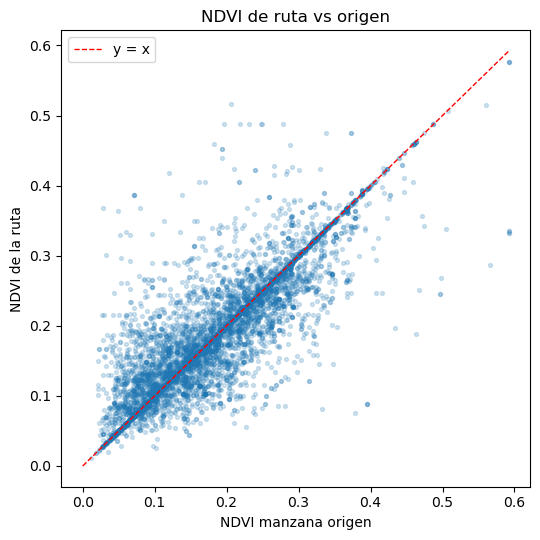

Correlación NDVI origen vs ruta: r = 0.855


In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(walkers['ndvi_mean'], walkers['ndvi_route'], alpha=0.2, s=8)
lims = [0, max(walkers['ndvi_mean'].max(), walkers['ndvi_route'].max())]
ax.plot(lims, lims, 'r--', lw=1, label='y = x')
ax.set_xlabel('NDVI manzana origen'); ax.set_ylabel('NDVI de la ruta')
ax.set_title('NDVI de ruta vs origen')
ax.legend(); plt.tight_layout(); plt.show()

r = walkers[['ndvi_mean', 'ndvi_route']].corr().iloc[0, 1]
print(f'Correlación NDVI origen vs ruta: r = {r:.3f}')

## 5. Mapa: orígenes por propósito + conectores origen→destino (muestra)

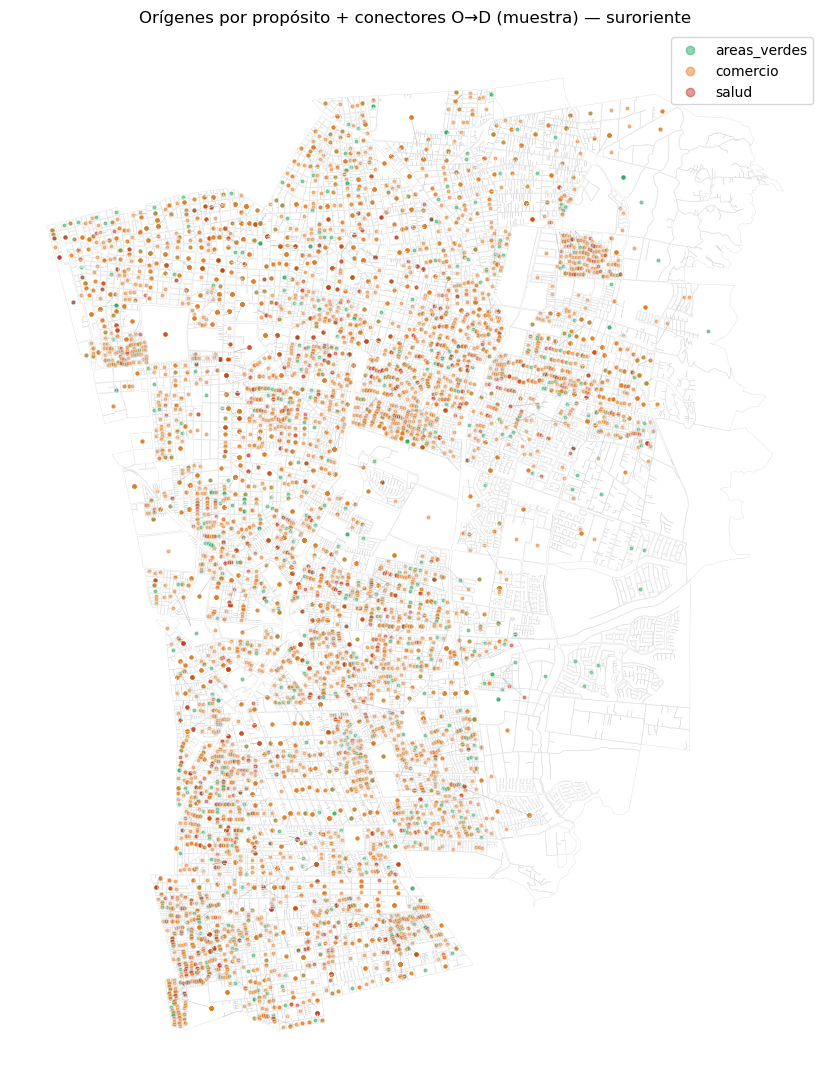

In [6]:
from shapely.geometry import LineString

colores = {'salud': '#c0392b', 'comercio': '#e67e22', 'areas_verdes': '#27ae60'}

fig, ax = plt.subplots(figsize=(11, 11))
manz.boundary.plot(ax=ax, color='#dddddd', linewidth=0.3)

# Conectores origen→destino de una muestra (chequeo de asignación de destino)
muestra = walkers.sample(min(400, len(walkers)), random_state=0)
lineas = gpd.GeoSeries(
    [LineString([(r.x_rep, r.y_rep), (r.x_dest, r.y_dest)]) for r in muestra.itertuples()],
    crs=cfg.CRS_PROJ)
lineas.plot(ax=ax, color='#999999', linewidth=0.4, alpha=0.5)

# Orígenes coloreados por propósito
for p, sub in walkers.groupby('purpose_group_model'):
    ax.scatter(sub['x_rep'], sub['y_rep'], s=4, alpha=0.5,
               color=colores.get(p, 'grey'), label=p)

ax.legend(markerscale=3, loc='upper right')
ax.set_title(f'Orígenes por propósito + conectores O→D (muestra) — {cfg.ZONA}')
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 6. Sanity checks numéricos

Cosas que deberían cumplirse si el artefacto está bien.

In [7]:
checks = {
    'sin NaN en route_length_m':     walkers['route_length_m'].notna().all(),
    'sin NaN en ndvi_route':         walkers['ndvi_route'].notna().all(),
    'todas las rutas <= umbral':     (walkers['route_length_m'] <= cfg.UMBRAL_CAMINATA_M).all(),
    'largos de ruta > 0':            (walkers['route_length_m'] > 0).all(),
    'ndvi_route en [0, 1]':          walkers['ndvi_route'].between(0, 1).all(),
    'agent_id único':                walkers['agent_id'].is_unique,
    'todos tienen dest_node':        walkers['dest_node'].notna().all(),
    '3 propósitos presentes':        walkers['purpose_group_model'].nunique() == 3,
}
for nombre, ok in checks.items():
    print(f'  [{"OK" if ok else "XX"}]  {nombre}')

assert all(checks.values()), 'Algún check falló — revisar antes de seguir'
print('\nTodos los checks pasaron.')

  [OK]  sin NaN en route_length_m
  [OK]  sin NaN en ndvi_route
  [OK]  todas las rutas <= umbral
  [OK]  largos de ruta > 0
  [OK]  ndvi_route en [0, 1]
  [OK]  agent_id único
  [OK]  todos tienen dest_node
  [OK]  3 propósitos presentes

Todos los checks pasaron.
